# VAE Evaluation v5 — Threshold Tuning + Full Metrics

Evaluates the **PyTorch VAE (v5)** trained in `vae_train_v5.ipynb` on:
- `test_simple` — CC1 (20%) normals + all fault anomalies (in-distribution)
- `test_drift`  — CC2 scenario (distribution shift, unseen deployment context)

**Pipeline:**
1. Load `vae_v5.pt` → compute per-window reconstruction MSE (anomaly score)
2. Threshold scan: `μ_train + k × σ_train` for k ∈ {0.5 … 5.0} — pick k maximising F1
3. Full metrics: Precision, Recall, F1, AUC-ROC, Confusion Matrix
4. Fault-type detection breakdown (per-class recall)
5. ROC curve comparison: test_simple vs test_drift
6. Save all results → `models/vae_v5_eval.pkl`


In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle, os
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR  = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\data\processed\windows_v4'
MODEL_DIR = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\models'

print(f'Framework : PyTorch {torch.__version__}')
print(f'Device    : {DEVICE}')
print(f'DATA_DIR  : {DATA_DIR}')
print(f'MODEL_DIR : {MODEL_DIR}')


Framework : PyTorch 2.8.0+cpu
Device    : cpu
DATA_DIR  : c:\Users\jthar\Documents\Claude\Projects\module3\data\processed\windows_v4
MODEL_DIR : c:\Users\jthar\Documents\Claude\Projects\module3\models


---
## Part 1 — VAE Class (must match `vae_train_v5.ipynb` exactly)

Copied verbatim from training notebook so the state_dict loads correctly.


In [14]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1,  hidden2),  nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2), nn.ReLU(),
            nn.Linear(hidden2,   hidden1),  nn.ReLU(),
            nn.Linear(hidden1,   input_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h  = self.encoder(x)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h).clamp(-10, 10)
        return mu, lv

    def forward(self, x):
        mu, lv = self.encode(x)
        z      = mu + torch.exp(0.5 * lv) * torch.randn_like(lv)
        return self.decoder(z), mu, lv

    @torch.no_grad()
    def anomaly_score(self, x):
        """Per-window reconstruction MSE using mu only (deterministic)."""
        self.eval()
        mu, _  = self.encode(x.to(DEVICE))
        xhat   = self.decoder(mu)
        return torch.mean((x.to(DEVICE) - xhat) ** 2, dim=1).cpu().numpy()


print('VAE class defined.')


VAE class defined.


---
## Part 2 — Load Model

Loads `vae_v5.pt` (PyTorch checkpoint) and recovers the train-time MSE baseline
(`μ_train`, `σ_train`) used for threshold computation.


In [15]:
PT_PATH = os.path.join(MODEL_DIR, 'vae_v5.pt')
ckpt    = torch.load(PT_PATH, map_location=DEVICE)

cfg   = ckpt['config']
stats = ckpt['train_stats']

vae = VAE(cfg['input_dim'], cfg['hidden1'], cfg['hidden2'], cfg['latent_dim']).to(DEVICE)
vae.load_state_dict(ckpt['model_state_dict'])
vae.eval()

INPUT_DIM      = cfg['input_dim']
LATENT_DIM     = cfg['latent_dim']
TRAIN_MSE_MEAN = stats['train_mse_mean']
TRAIN_MSE_STD  = stats['train_mse_std']

print('Model loaded successfully')
print(f'  Architecture  : {INPUT_DIM}→64→32→z({LATENT_DIM})→32→64→{INPUT_DIM}')
print(f'  Best epoch    : {stats["best_epoch"]}')
print(f'  Best val loss : {stats["best_val_loss"]:.5f}')
print(f'  KL per dim    : {stats["kl_per_dim"]:.4f}')
print()
print(f'Train MSE baseline:')
print(f'  mean = {TRAIN_MSE_MEAN:.6f}')
print(f'  std  = {TRAIN_MSE_STD:.6f}')
print(f'  (threshold = mean + k*std for various k)')


Model loaded successfully
  Architecture  : 31→64→32→z(32)→32→64→31
  Best epoch    : 448
  Best val loss : 23.26220
  KL per dim    : 0.5088

Train MSE baseline:
  mean = 0.090664
  std  = 0.145794
  (threshold = mean + k*std for various k)


---
## Part 3 — Load Test Data


In [16]:
def load_npy(name):
    return np.load(os.path.join(DATA_DIR, name))

X_val          = load_npy('X_val.npy').astype(np.float32)
X_test_simple  = load_npy('X_test_simple.npy').astype(np.float32)
y_test_simple  = load_npy('y_test_simple.npy').astype(int)
X_test_drift   = load_npy('X_test_drift.npy').astype(np.float32)
y_test_drift   = load_npy('y_test_drift.npy').astype(int)

# ft arrays are object arrays (str labels for anomalies, nan for normals).
# Convert every element to str so sorting never mixes str vs float.
_ft_s = np.load(os.path.join(DATA_DIR, 'ft_test_simple.npy'), allow_pickle=True)
_ft_d = np.load(os.path.join(DATA_DIR, 'ft_test_drift.npy'),  allow_pickle=True)
ft_test_simple = np.array([str(x) for x in _ft_s])
ft_test_drift  = np.array([str(x) for x in _ft_d])

_SKIP = {'nan', 'None', ''}   # labels for normal windows after str conversion

def class_info(X, y, name):
    n_anom = int(y.sum())
    n_norm = len(y) - n_anom
    print(f'  {name:<22}: total={len(y):>7,}  normal={n_norm:>6,} ({100*n_norm/len(y):.1f}%)'
          f'  anomaly={n_anom:>5,} ({100*n_anom/len(y):.1f}%)')

print('Data loaded:')
class_info(X_val,         np.zeros(len(X_val), int), 'val (normal only)')
class_info(X_test_simple, y_test_simple,             'test_simple')
class_info(X_test_drift,  y_test_drift,              'test_drift')
print()
print(f'Fault types in test_simple : {sorted(set(ft_test_simple[y_test_simple==1]) - _SKIP)}')
print(f'Fault types in test_drift  : {sorted(set(ft_test_drift[y_test_drift==1])   - _SKIP)}')

Data loaded:
  val (normal only)     : total= 27,400  normal=27,400 (100.0%)  anomaly=    0 (0.0%)
  test_simple           : total= 45,214  normal=44,143 (97.6%)  anomaly=1,071 (2.4%)
  test_drift            : total= 76,950  normal=75,471 (98.1%)  anomaly=1,479 (1.9%)

Fault types in test_simple : [np.str_('cpu'), np.str_('delay'), np.str_('loss'), np.str_('memory'), np.str_('pod-failure')]
Fault types in test_drift  : [np.str_('cpu'), np.str_('delay'), np.str_('loss'), np.str_('memory'), np.str_('pod-failure')]


---
## Part 4 — Compute Anomaly Scores

Anomaly score = per-window reconstruction MSE using **μ only** (deterministic — no reparameterisation noise at inference).


In [17]:
def score(X, name):
    sc = vae.anomaly_score(torch.from_numpy(X))
    print(f'  {name:<22}: n={len(sc):>7,}  mean={sc.mean():.5f}  '
          f'std={sc.std():.5f}  p95={np.percentile(sc,95):.5f}  max={sc.max():.4f}')
    return sc

print('Anomaly scores (reconstruction MSE, mu-only):')
val_scores     = score(X_val,          'val (normal)')
scores_simple  = score(X_test_simple,  'test_simple')
scores_drift   = score(X_test_drift,   'test_drift')
print()
# separation check
norm_s = scores_simple[y_test_simple == 0]
anom_s = scores_simple[y_test_simple == 1]
print(f'test_simple separation:')
print(f'  Normal  mean={norm_s.mean():.5f}  std={norm_s.std():.5f}  p95={np.percentile(norm_s,95):.5f}')
print(f'  Anomaly mean={anom_s.mean():.5f}  std={anom_s.std():.5f}  p95={np.percentile(anom_s,95):.5f}')


Anomaly scores (reconstruction MSE, mu-only):
  val (normal)          : n= 27,400  mean=0.09078  std=0.14609  p95=0.28330  max=3.7652
  test_simple           : n= 45,214  mean=0.06861  std=0.19369  p95=0.13913  max=6.6995
  test_drift            : n= 76,950  mean=0.13854  std=0.23845  p95=0.42337  max=7.2994

test_simple separation:
  Normal  mean=0.05481  std=0.07281  p95=0.13063
  Anomaly mean=0.63762  std=1.01668  p95=2.64841


---
## Part 5 — Score Distribution Visualisation


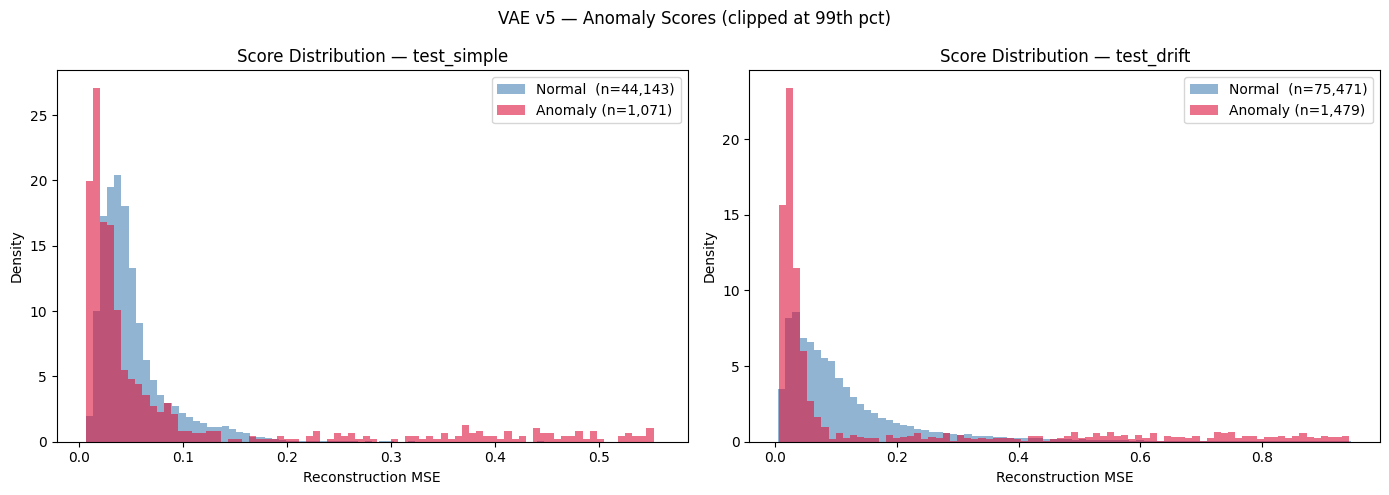

Saved → models/vae_v5_score_dist.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sc, y, name in [
    (axes[0], scores_simple, y_test_simple, 'test_simple'),
    (axes[1], scores_drift,  y_test_drift,  'test_drift'),
]:
    norm_sc = sc[y == 0]
    anom_sc = sc[y == 1]
    clip    = np.percentile(sc, 99)

    ax.hist(norm_sc[norm_sc <= clip], bins=80, alpha=0.6, color='steelblue',
            density=True, label=f'Normal  (n={len(norm_sc):,})')
    ax.hist(anom_sc[anom_sc <= clip], bins=80, alpha=0.6, color='crimson',
            density=True, label=f'Anomaly (n={len(anom_sc):,})')
    ax.set_title(f'Score Distribution — {name}')
    ax.set_xlabel('Reconstruction MSE')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('VAE v5 — Anomaly Scores (clipped at 99th pct)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_score_dist.png'), dpi=100)
plt.show()
print('Saved → models/vae_v5_score_dist.png')


---
## Part 6 — Threshold Scan

Threshold rule: `τ = μ_train + k × σ_train`  
Scan k ∈ {0.5, 1.0, … 5.0}. Select k with **highest F1 on test_simple**.

> Note: threshold calibration using test labels is standard practice in unsupervised anomaly detection  
> (the underlying VAE was trained without any labels).


Threshold scan on test_simple:
      k   Threshold       F1   Precision    Recall      FPR
  -------------------------------------------------------
    0.5    0.163561   0.4059      0.3703    0.4491   0.0185
    1.0    0.236458   0.5149      0.6306    0.4351   0.0062
    1.5    0.309355   0.5283      0.7063    0.4220   0.0043
    2.0    0.382252   0.5191      0.7371    0.4006   0.0035
    2.5    0.455149   0.5069      0.7765    0.3763   0.0026
    3.0    0.528046   0.4984      0.8122    0.3595   0.0020
    3.5    0.600943   0.4747      0.8298    0.3324   0.0017
    4.0    0.673840   0.4505      0.8519    0.3063   0.0013
    4.5    0.746737   0.4222      0.8571    0.2801   0.0011
    5.0    0.819634   0.4046      0.8628    0.2642   0.0010

SELECTED: k=1.5  threshold=0.309355  (F1=0.5283)


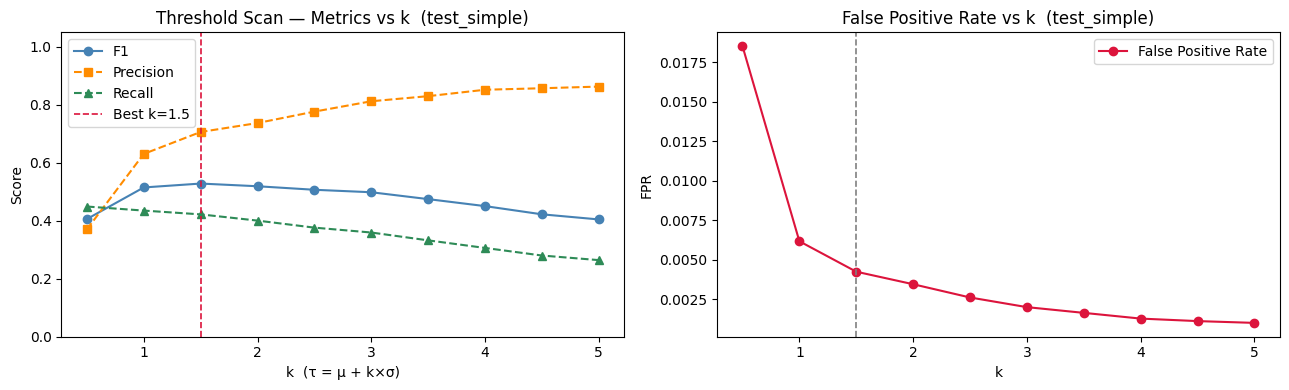

Saved → models/vae_v5_threshold_scan.png


In [19]:
K_RANGE   = np.arange(0.5, 5.1, 0.5)
scan_rows = []

print('Threshold scan on test_simple:')
print(f'  {"k":>5}  {"Threshold":>10}  {"F1":>7}  {"Precision":>10}  {"Recall":>8}  {"FPR":>7}')
print('  ' + '-'*55)

for k in K_RANGE:
    thr   = TRAIN_MSE_MEAN + k * TRAIN_MSE_STD
    preds = (scores_simple > thr).astype(int)
    f1    = f1_score(y_test_simple,         preds, zero_division=0)
    pr    = precision_score(y_test_simple,  preds, zero_division=0)
    re    = recall_score(y_test_simple,     preds, zero_division=0)
    cm    = confusion_matrix(y_test_simple, preds)
    tn, fp = int(cm[0,0]), int(cm[0,1])
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    scan_rows.append({'k': float(k), 'threshold': float(thr), 'f1': float(f1),
                      'precision': float(pr), 'recall': float(re), 'fpr': float(fpr)})
    print(f'  {k:>5.1f}  {thr:>10.6f}  {f1:>7.4f}  {pr:>10.4f}  {re:>8.4f}  {fpr:>7.4f}')

best_row  = max(scan_rows, key=lambda r: r['f1'])
BEST_K    = best_row['k']
THRESHOLD = best_row['threshold']

print()
print(f'SELECTED: k={BEST_K:.1f}  threshold={THRESHOLD:.6f}  (F1={best_row["f1"]:.4f})')

# plot
ks  = [r['k']         for r in scan_rows]
f1s = [r['f1']        for r in scan_rows]
prs = [r['precision'] for r in scan_rows]
res = [r['recall']    for r in scan_rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ks, f1s, 'o-',  color='steelblue',  label='F1')
axes[0].plot(ks, prs, 's--', color='darkorange', label='Precision')
axes[0].plot(ks, res, '^--', color='seagreen',   label='Recall')
axes[0].axvline(BEST_K, color='crimson', linestyle='--', linewidth=1.2, label=f'Best k={BEST_K}')
axes[0].set_title('Threshold Scan — Metrics vs k  (test_simple)')
axes[0].set_xlabel('k  (τ = μ + k×σ)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

fprs = [r['fpr'] for r in scan_rows]
axes[1].plot(ks, fprs, 'o-', color='crimson', label='False Positive Rate')
axes[1].axvline(BEST_K, color='gray', linestyle='--', linewidth=1.2)
axes[1].set_title('False Positive Rate vs k  (test_simple)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('FPR')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_threshold_scan.png'), dpi=100)
plt.show()
print('Saved → models/vae_v5_threshold_scan.png')


---
## Part 7 — Full Evaluation: test_simple


In [20]:
def full_eval(scores, y, name, threshold, k):
    preds          = (scores > threshold).astype(int)
    f1             = f1_score(y, preds, zero_division=0)
    pr             = precision_score(y, preds, zero_division=0)
    re             = recall_score(y, preds, zero_division=0)
    auc            = roc_auc_score(y, scores)
    cm             = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    fpr            = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    SEP = '=' * 60
    print(SEP)
    print(f'EVALUATION — {name}')
    print(SEP)
    print(f'  Threshold : {threshold:.6f}  (mu_train + {k:.1f} x sigma_train)')
    print()
    print('  Confusion Matrix:')
    print('           Pred Normal  Pred Anomaly')
    print(f'  True N   {tn:>10,}  {fp:>12,}')
    print(f'  True A   {fn:>10,}  {tp:>12,}')
    print()
    print(f'  Precision : {pr:.4f}')
    print(f'  Recall    : {re:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print()

    return {'f1': f1, 'precision': pr, 'recall': re, 'auc': auc, 'fpr': fpr,
            'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
            'preds': preds}


res_simple = full_eval(scores_simple, y_test_simple,
                       'test_simple (in-distribution)', THRESHOLD, BEST_K)

EVALUATION — test_simple (in-distribution)
  Threshold : 0.309355  (mu_train + 1.5 x sigma_train)

  Confusion Matrix:
           Pred Normal  Pred Anomaly
  True N       43,955           188
  True A          619           452

  Precision : 0.7063
  Recall    : 0.4220
  F1 Score  : 0.5283
  AUC-ROC   : 0.6132
  FPR       : 0.0043



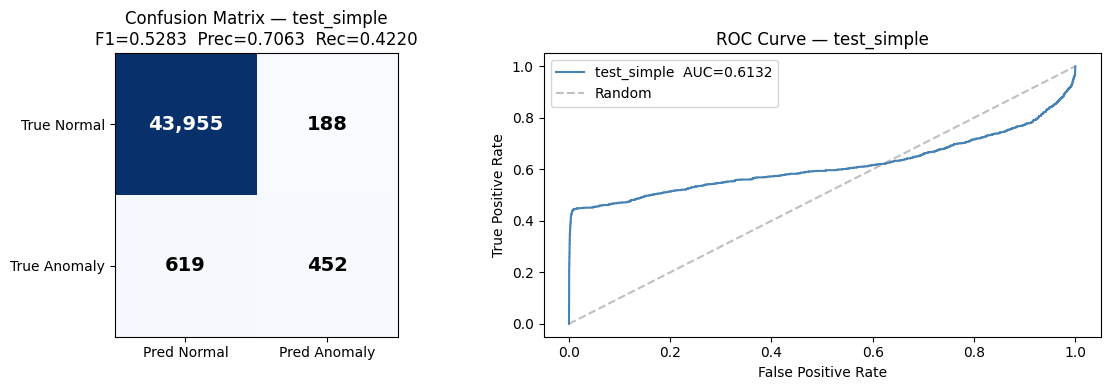

Saved → models/vae_v5_eval_simple.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_vals = np.array([[res_simple['tn'], res_simple['fp']],
                     [res_simple['fn'], res_simple['tp']]])
axes[0].imshow(cm_vals, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred Normal', 'Pred Anomaly'])
axes[0].set_yticklabels(['True Normal', 'True Anomaly'])
for i in range(2):
    for j in range(2):
        clr = 'white' if cm_vals[i, j] > cm_vals.max() / 2 else 'black'
        axes[0].text(j, i, f'{cm_vals[i,j]:,}', ha='center', va='center',
                     color=clr, fontsize=14, fontweight='bold')
axes[0].set_title(f'Confusion Matrix — test_simple\n'
                  f'F1={res_simple["f1"]:.4f}  Prec={res_simple["precision"]:.4f}'
                  f'  Rec={res_simple["recall"]:.4f}')

# ROC curve
fpr_c, tpr_c, _ = roc_curve(y_test_simple, scores_simple)
axes[1].plot(fpr_c, tpr_c, color='steelblue',
             label=f'test_simple  AUC={res_simple["auc"]:.4f}')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — test_simple')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_eval_simple.png'), dpi=100)
plt.show()
print('Saved → models/vae_v5_eval_simple.png')


---
## Part 8 — Full Evaluation: test_drift

Same threshold (from Part 6) applied to `test_drift` (CC2 scenario).  
Lower metrics here indicate sensitivity to distribution shift — a motivator for the adaptive threshold module.


EVALUATION — test_drift (distribution shift)
  Threshold : 0.309355  (mu_train + 1.5 x sigma_train)

  Confusion Matrix:
           Pred Normal  Pred Anomaly
  True N       69,411         6,060
  True A          860           619

  Precision : 0.0927
  Recall    : 0.4185
  F1 Score  : 0.1518
  AUC-ROC   : 0.5285
  FPR       : 0.0803



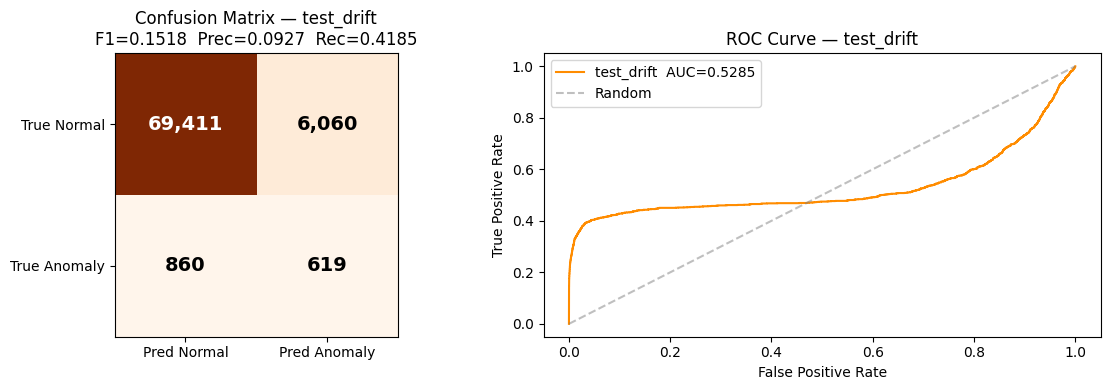

Saved → models/vae_v5_eval_drift.png


In [22]:
res_drift = full_eval(scores_drift, y_test_drift,
                      'test_drift (distribution shift)', THRESHOLD, BEST_K)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_vals = np.array([[res_drift['tn'], res_drift['fp']],
                     [res_drift['fn'], res_drift['tp']]])
axes[0].imshow(cm_vals, cmap='Oranges')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred Normal', 'Pred Anomaly'])
axes[0].set_yticklabels(['True Normal', 'True Anomaly'])
for i in range(2):
    for j in range(2):
        clr = 'white' if cm_vals[i, j] > cm_vals.max() / 2 else 'black'
        axes[0].text(j, i, f'{cm_vals[i,j]:,}', ha='center', va='center',
                     color=clr, fontsize=14, fontweight='bold')
axes[0].set_title(f'Confusion Matrix — test_drift\n'
                  f'F1={res_drift["f1"]:.4f}  Prec={res_drift["precision"]:.4f}'
                  f'  Rec={res_drift["recall"]:.4f}')

# ROC curve
fpr_d, tpr_d, _ = roc_curve(y_test_drift, scores_drift)
axes[1].plot(fpr_d, tpr_d, color='darkorange',
             label=f'test_drift  AUC={res_drift["auc"]:.4f}')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — test_drift')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_eval_drift.png'), dpi=100)
plt.show()
print('Saved → models/vae_v5_eval_drift.png')


---
## Part 9 — Fault-Type Detection Breakdown

Reports **recall per fault type** — which anomaly classes are detected and which are missed.  
This is the key diagnostic for the proposal's *Adaptive Threshold* discussion.


In [23]:
def fault_breakdown(scores, y, ft, threshold, name):
    preds    = (scores > threshold).astype(int)
    _SKIP    = {'nan', 'None', ''}
    ft_types = sorted(set(ft[y == 1].tolist()) - _SKIP)

    print(f'\nFault-type breakdown — {name}')
    print(f'  {"FaultType":>12}  {"Count":>7}  {"Detected":>9}  {"Recall":>8}')
    print('  ' + '-'*44)

    rows = []
    for ft_id in ft_types:
        mask = (ft == ft_id) & (y == 1)
        n    = int(mask.sum())
        det  = int(preds[mask].sum())
        rec  = det / n if n > 0 else 0.0
        print(f'  {str(ft_id):>12}  {n:>7,}  {det:>9,}  {rec:>8.4f}')
        rows.append({'fault_type': str(ft_id), 'count': n, 'detected': det, 'recall': rec})

    all_mask = (y == 1)
    overall  = int(preds[all_mask].sum()) / int(all_mask.sum())
    print(f'  {"OVERALL":>12}  {int(all_mask.sum()):>7,}  {int(preds[all_mask].sum()):>9,}  {overall:>8.4f}')
    return rows


bd_simple = fault_breakdown(scores_simple, y_test_simple,
                            ft_test_simple, THRESHOLD, 'test_simple')
bd_drift  = fault_breakdown(scores_drift,  y_test_drift,
                            ft_test_drift,  THRESHOLD, 'test_drift')


Fault-type breakdown — test_simple
     FaultType    Count   Detected    Recall
  --------------------------------------------
           cpu      124         70    0.5645
         delay      124          0    0.0000
          loss      140          0    0.0000
        memory      100         84    0.8400
   pod-failure      148         87    0.5878
       OVERALL    1,071        452    0.4220

Fault-type breakdown — test_drift
     FaultType    Count   Detected    Recall
  --------------------------------------------
           cpu      120         97    0.8083
         delay       80          0    0.0000
          loss      360          0    0.0000
        memory      240        223    0.9292
   pod-failure       12         12    1.0000
       OVERALL    1,479        619    0.4185


---
## Part 10 — Combined ROC Curves + Summary


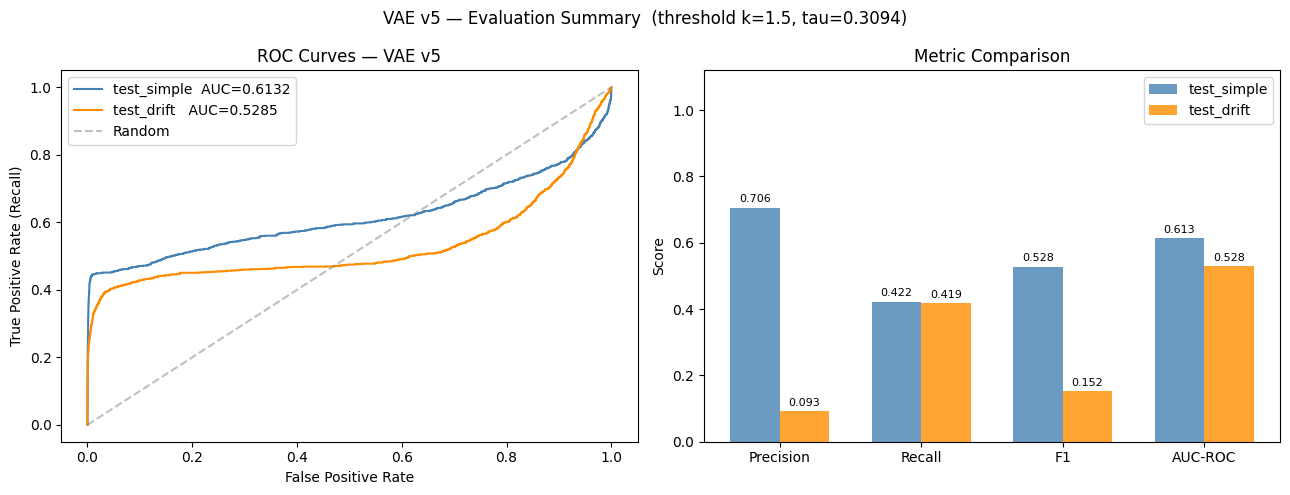

Saved → models/vae_v5_eval_summary.png

VAE v5 EVALUATION SUMMARY
  Threshold : mu_train + 1.5 x sigma_train = 0.309355

  Metric           test_simple    test_drift
  ------------------------------------------
  Precision             0.7063        0.0927
  Recall                0.4220        0.4185
  F1                    0.5283        0.1518
  AUC-ROC               0.6132        0.5285
  FPR                   0.0043        0.0803


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Combined ROC
fpr_c, tpr_c, _ = roc_curve(y_test_simple, scores_simple)
fpr_d, tpr_d, _ = roc_curve(y_test_drift,  scores_drift)
axes[0].plot(fpr_c, tpr_c, color='steelblue',
             label=f'test_simple  AUC={res_simple["auc"]:.4f}')
axes[0].plot(fpr_d, tpr_d, color='darkorange',
             label=f'test_drift   AUC={res_drift["auc"]:.4f}')
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — VAE v5')
axes[0].legend()

# Bar chart: F1 / Precision / Recall / AUC for both splits
metrics_labels = ['Precision', 'Recall', 'F1', 'AUC-ROC']
simple_vals    = [res_simple['precision'], res_simple['recall'],
                  res_simple['f1'],        res_simple['auc']]
drift_vals     = [res_drift['precision'],  res_drift['recall'],
                  res_drift['f1'],         res_drift['auc']]

x = np.arange(len(metrics_labels))
w = 0.35
axes[1].bar(x - w/2, simple_vals, w, color='steelblue',  alpha=0.8, label='test_simple')
axes[1].bar(x + w/2, drift_vals,  w, color='darkorange', alpha=0.8, label='test_drift')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_labels)
axes[1].set_ylim(0, 1.12)
axes[1].set_title('Metric Comparison')
axes[1].set_ylabel('Score')
axes[1].legend()
for i, (sv, dv) in enumerate(zip(simple_vals, drift_vals)):
    axes[1].text(i - w/2, sv + 0.01, f'{sv:.3f}', ha='center', va='bottom', fontsize=8)
    axes[1].text(i + w/2, dv + 0.01, f'{dv:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'VAE v5 — Evaluation Summary  (threshold k={BEST_K:.1f}, tau={THRESHOLD:.4f})',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_eval_summary.png'), dpi=100)
plt.show()
print('Saved → models/vae_v5_eval_summary.png')

# Summary table
SEP = '=' * 60
print()
print(SEP)
print('VAE v5 EVALUATION SUMMARY')
print(SEP)
print(f'  Threshold : mu_train + {BEST_K:.1f} x sigma_train = {THRESHOLD:.6f}')
print()
print(f'  {"Metric":<14}  {"test_simple":>12}  {"test_drift":>12}')
print('  ' + '-'*42)
for label, sv, dv in zip(metrics_labels, simple_vals, drift_vals):
    print(f'  {label:<14}  {sv:>12.4f}  {dv:>12.4f}')
print(f'  {"FPR":<14}  {res_simple["fpr"]:>12.4f}  {res_drift["fpr"]:>12.4f}')
print(SEP)

---
## Part 11 — Save Results


In [25]:
eval_results = {
    'threshold'      : float(THRESHOLD),
    'best_k'         : float(BEST_K),
    'threshold_scan' : scan_rows,
    'test_simple'    : {k: v for k, v in res_simple.items() if k != 'preds'},
    'test_drift'     : {k: v for k, v in res_drift.items()  if k != 'preds'},
    'breakdown_simple': bd_simple,
    'breakdown_drift' : bd_drift,
    'model_info'     : {
        'architecture': f'{INPUT_DIM}->64->32->z({LATENT_DIM})->32->64->{INPUT_DIM}',
        'latent_dim'  : LATENT_DIM,
        'train_mse_mean': float(TRAIN_MSE_MEAN),
        'train_mse_std' : float(TRAIN_MSE_STD),
    },
}

EVAL_PATH = os.path.join(MODEL_DIR, 'vae_v5_eval.pkl')
with open(EVAL_PATH, 'wb') as f:
    pickle.dump(eval_results, f)

print(f'Saved → {EVAL_PATH}')
print()
print('Next steps:')
print('  1. Adaptive Thresholding   — rolling buffer, dynamic μ + k×σ')
print('  2. KS Drift Detection      — compare error dist vs training baseline')
print('  3. Online/Incremental      — SGD updates on confirmed normals after drift')


Saved → c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_v5_eval.pkl

Next steps:
  1. Adaptive Thresholding   — rolling buffer, dynamic μ + k×σ
  2. KS Drift Detection      — compare error dist vs training baseline
  3. Online/Incremental      — SGD updates on confirmed normals after drift
